# GenAI Strategy–Implementation Gap Analysis
**Bachelor Thesis — Text Mining of German Mittelstand Annual Reports**

Extracts AI-related language from annual report PDFs and computes a **gap ratio**  
(strategic AI talk vs. operational AI deployment language) per company.

**To add a report:** drop the PDF into `reports/` and re-run all cells.

In [1]:
%pip install pdfplumber pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pdfplumber
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

REPORTS_DIR  = Path("reports")
CSV_SUMMARY  = Path("ai_gap_results.csv")
CSV_DETAIL   = Path("ai_keyword_detail.csv")
CSV_CONTEXTS = Path("ai_keyword_contexts.csv")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

## Keyword Lists

**Strategic** = vision, planning, ambition language (what AI *will* or *could* do).  
**Operational** = deployment, implementation, production language (AI actually *in use*).  

Extend either list to refine the analysis.

In [3]:
STRATEGIC_KEYWORDS = [
    # Standalone AI mention (strategic framing)
    "artificial intelligence",
    # Core strategic phrases
    "ai strategy", "artificial intelligence strategy", "ai roadmap", "ai vision",
    "ai initiative", "ai investment", "ai potential", "ai opportunity",
    "ai transformation", "digital transformation", "future of ai",
    "generative ai strategy",
    # Intent / planning
    "plan to use ai", "plan to use artificial intelligence",
    "intend to implement", "exploring ai", "exploring artificial intelligence",
    "evaluating ai", "evaluating artificial intelligence", "pilot phase",
    "invest in ai", "investing in ai",
    # AI modal verbs (what AI *will/could/may* do)
    "ai will", "ai could", "ai may", "ai can",
    # Other strategic signals
    "ai agenda", "ai ambition", "ai capability", "ai budget",
    "genai", "gen-ai", "ai-driven transformation", "ai-powered future",
    "build ai", "develop ai", "assess ai", "strategic ai", "ai-first",
    "leverage ai", "harness ai", "unlock ai",
]

OPERATIONAL_KEYWORDS = [
    # Direct AI-compound operational phrases
    "we use ai", "using ai", "ai is used", "ai helps", "our ai",
    "ai-based", "ai supported", "supported by ai",
    "with the help of ai", "thanks to ai", "through ai", "via ai",
    "we use artificial intelligence", "using artificial intelligence",
    "uses artificial intelligence", "artificial intelligence to",
    "machine learning to", "powered by ai", "powered by machine learning",
    "automated using ai", "automated using artificial intelligence",
    # Specific AI technologies (self-evidently operational)
    "predictive maintenance", "quality control ai", "ai-based quality",
    "generative ai", "copilot", "chatbot", "chatbot deployed",
    "image recognition", "natural language processing",
    "computer vision", "recommendation system",
    # AI deployment compound phrases
    "ai-powered", "ai-driven", "ai-enabled", "ai-assisted",
    "ai deployment", "ai rollout", "ai implementation", "ai integration",
    "ai system", "ai tool", "ai solution", "ai model", "ai application",
    "machine learning model", "large language model", "llm",
    "ai use case", "ai pilot", "ai project", "ai automation",
    "ai team", "ai platform", "training data", "fine-tuned",
]

# Ambiguous terms — only counted when within CONTEXT_WINDOW characters of an AI anchor.
OPERATIONAL_CONTEXT_KEYWORDS = [
    "automated", "successfully deployed", "already using",
]

CONTEXT_WINDOW = 150  # characters either side of the keyword

AI_ANCHOR = re.compile(
    r'\b(ai|artificial intelligence|machine learning|deep learning|'
    r'neural network|llm|algorithm|generative)\b'
)

print(f"Strategic keywords:           {len(STRATEGIC_KEYWORDS)}")
print(f"Operational keywords:         {len(OPERATIONAL_KEYWORDS)}")
print(f"Operational context keywords: {len(OPERATIONAL_CONTEXT_KEYWORDS)}")

Strategic keywords:           43
Operational keywords:         56
Operational context keywords: 3


## PDF Extraction & Text Normalization

In [4]:
def normalize_text(text: str) -> str:
    """Rejoin hyphenated line-breaks and collapse whitespace."""
    text = re.sub(r'-\n\s*', '', text)   # "tech-\nnologies" → "technologies"
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def extract_text(pdf_path: Path) -> str:
    pages = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            t = page.extract_text()
            if t:
                pages.append(t)
    return normalize_text("\n".join(pages))


def get_sentences(text: str) -> list[str]:
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.strip()) > 20]


def company_name_from_path(path: Path) -> str:
    """Convert filename to a readable company label."""
    stem = path.stem
    # Preserve known all-caps abbreviations before title-casing
    for token in ("AG", "SE", "GmbH", "KG"):
        stem = re.sub(rf'(?i)\b{token}\b', token, stem)
    stem = re.sub(r'[_-]+', ' ', stem).strip()
    # Title-case word by word, but keep abbreviations intact
    return ' '.join(w if w.isupper() else w.capitalize() for w in stem.split())

## Frequency Analysis

In [5]:
def count_keywords(text: str, keywords: list[str]) -> dict[str, int]:
    """Whole-word, case-insensitive keyword counts."""
    text_lower = text.lower()
    return {
        kw: len(re.findall(r'\b' + re.escape(kw) + r'\b', text_lower))
        for kw in keywords
    }


def count_context_keywords(text: str, keywords: list[str], window: int = CONTEXT_WINDOW) -> dict[str, int]:
    """Count keyword hits only when they occur within `window` chars of an AI anchor term.
    This prevents generic words like 'automated' from matching non-AI sentences."""
    text_lower = text.lower()
    anchor_positions = [m.start() for m in AI_ANCHOR.finditer(text_lower)]
    counts = {}
    for kw in keywords:
        pattern = re.compile(r'\b' + re.escape(kw) + r'\b')
        total = sum(
            1 for m in pattern.finditer(text_lower)
            if any(abs(m.start() - a) <= window for a in anchor_positions)
        )
        counts[kw] = total
    return counts


def extract_contexts(sentences: list[str], keywords: list[str], company: str, category: str) -> list[dict]:
    rows = []
    for sent in sentences:
        sent_lower = sent.lower()
        for kw in keywords:
            if re.search(r'\b' + re.escape(kw) + r'\b', sent_lower):
                rows.append({"company": company, "category": category, "keyword": kw, "sentence": sent})
    return rows

## Run Analysis on All Reports

In [6]:
SILENCE_THRESHOLD = 1.0  # total AI mentions per 10,000 words — below this = AI-silent

results   = []
kw_detail = []
contexts  = []

pdf_files = sorted(REPORTS_DIR.glob("*.pdf"))
print(f"Found {len(pdf_files)} reports  |  context window = ±{CONTEXT_WINDOW} chars  |  silence threshold = {SILENCE_THRESHOLD}/10k words\n")

for pdf_path in pdf_files:
    company = company_name_from_path(pdf_path)
    print(f"  {company:<35} ", end="")

    text      = extract_text(pdf_path)
    sentences = get_sentences(text)

    total_words = max(len(text.split()), 1)  # avoid div-by-zero

    strat    = count_keywords(text, STRATEGIC_KEYWORDS)
    oper     = count_keywords(text, OPERATIONAL_KEYWORDS)
    oper_ctx = count_context_keywords(text, OPERATIONAL_CONTEXT_KEYWORDS)

    s_total = sum(strat.values())
    o_total = sum(oper.values()) + sum(oper_ctx.values())
    total   = s_total + o_total
    ratio   = round(s_total / (o_total + 1), 4)

    # Normalise to per-10,000 words
    s_per10k = round((s_total / total_words) * 10_000, 3)
    o_per10k = round((o_total / total_words) * 10_000, 3)
    t_per10k = round((total   / total_words) * 10_000, 3)

    # Classify
    if t_per10k < SILENCE_THRESHOLD:
        classification = "AI-Silent"
    elif ratio > 1.5:
        classification = "Strategic-Dominant"
    elif ratio < 0.67:
        classification = "Operational-Dominant"
    else:
        classification = "Balanced"

    print(f"strategic={s_total:3d} ({s_per10k:.2f}/10k)  operational={o_total:3d} ({o_per10k:.2f}/10k)  "
          f"gap={ratio:.3f}  [{classification}]")

    results.append({
        "company":                  company,
        "source_file":              pdf_path.name,
        "total_words":              total_words,
        "strategic_hits":           s_total,
        "operational_hits":         o_total,
        "operational_context_hits": sum(oper_ctx.values()),
        "gap_ratio":                ratio,
        "total_ai_mentions":        total,
        "strategic_per_10k":        s_per10k,
        "operational_per_10k":      o_per10k,
        "total_per_10k":            t_per10k,
        "classification":           classification,
    })

    for kw, cnt in strat.items():
        if cnt > 0:
            kw_detail.append({"company": company, "category": "strategic", "keyword": kw, "count": cnt})
    for kw, cnt in {**oper, **oper_ctx}.items():
        if cnt > 0:
            kw_detail.append({"company": company, "category": "operational", "keyword": kw, "count": cnt})

    contexts.extend(extract_contexts(sentences, STRATEGIC_KEYWORDS,          company, "strategic"))
    contexts.extend(extract_contexts(sentences, OPERATIONAL_KEYWORDS,         company, "operational"))
    contexts.extend(extract_contexts(sentences, OPERATIONAL_CONTEXT_KEYWORDS, company, "operational_context"))

df = pd.DataFrame(results).sort_values("gap_ratio", ascending=False).reset_index(drop=True)
df_detail   = pd.DataFrame(kw_detail).sort_values(["company", "count"], ascending=[True, False])
df_contexts = pd.DataFrame(contexts).drop_duplicates(subset=["company", "sentence"])

df.to_csv(CSV_SUMMARY,  index=False)
df_detail.to_csv(CSV_DETAIL,   index=False)
df_contexts.to_csv(CSV_CONTEXTS, index=False)

print(f"\nSaved: {CSV_SUMMARY}, {CSV_DETAIL}, {CSV_CONTEXTS}")

Found 15 reports  |  context window = ±150 chars  |  silence threshold = 1.0/10k words

  ATOSS                               

strategic= 17 (1.92/10k)  operational= 28 (3.17/10k)  gap=0.586  [Operational-Dominant]


  Bechtle                             

strategic= 32 (2.52/10k)  operational=  4 (0.32/10k)  gap=6.400  [Strategic-Dominant]


  Dermapharm SE                       

...

  TRUMPF                              

strategic=  8 (2.37/10k)  operational=  6 (1.77/10k)  gap=1.143  [Balanced]


  Wacker Neuson                       

strategic=  0 (0.00/10k)  operational=  0 (0.00/10k)  gap=0.000  [AI-Silent]



Saved: ai_gap_results.csv, ai_keyword_detail.csv, ai_keyword_contexts.csv


## Summary Table

In [7]:
display_cols = ["company", "total_words", "strategic_hits", "operational_hits",
                "strategic_per_10k", "operational_per_10k", "total_per_10k",
                "gap_ratio", "classification"]

df[display_cols].style \
    .background_gradient(subset=["gap_ratio"],            cmap="RdYlGn_r") \
    .background_gradient(subset=["strategic_per_10k",
                                  "operational_per_10k",
                                  "total_per_10k"],        cmap="Blues") \
    .map(lambda v: "background-color: #f0f0f0; color: #999",
         subset=pd.IndexSlice[df["classification"] == "AI-Silent", :]) \
    .format({"gap_ratio":             "{:.3f}",
             "strategic_per_10k":     "{:.2f}",
             "operational_per_10k":   "{:.2f}",
             "total_per_10k":         "{:.2f}",
             "total_words":           "{:,}"}) \
    .hide(axis="index")

company,total_words,strategic_hits,operational_hits,strategic_per_10k,operational_per_10k,total_per_10k,gap_ratio,classification
Bechtle,"126,914",32,4,2.52,0.32,2.84,6.400,Strategic-Dominant
Deutz AG,"150,379",3,0,0.20,0.00,0.20,3.000,AI-Silent
Krones,"118,070",9,2,0.76,0.17,0.93,3.000,AI-Silent
SUSS Microtec SE,"120,528",5,1,0.41,0.08,0.50,2.500,AI-Silent
Rational AG,"99,997",2,0,0.20,0.00,0.20,2.000,AI-Silent
Secunet,"84,814",12,5,1.42,0.59,2.00,2.000,Strategic-Dominant
Durr,"170,607",13,6,0.76,0.35,1.11,1.857,Strategic-Dominant
Nemetscheck Group,"18,406",17,9,9.24,4.89,14.13,1.700,Strategic-Dominant
Jenoptik,"126,466",10,6,0.79,0.47,1.26,1.429,Balanced
TRUMPF,"33,804",8,6,2.37,1.77,4.14,1.143,Balanced


## Visualisations

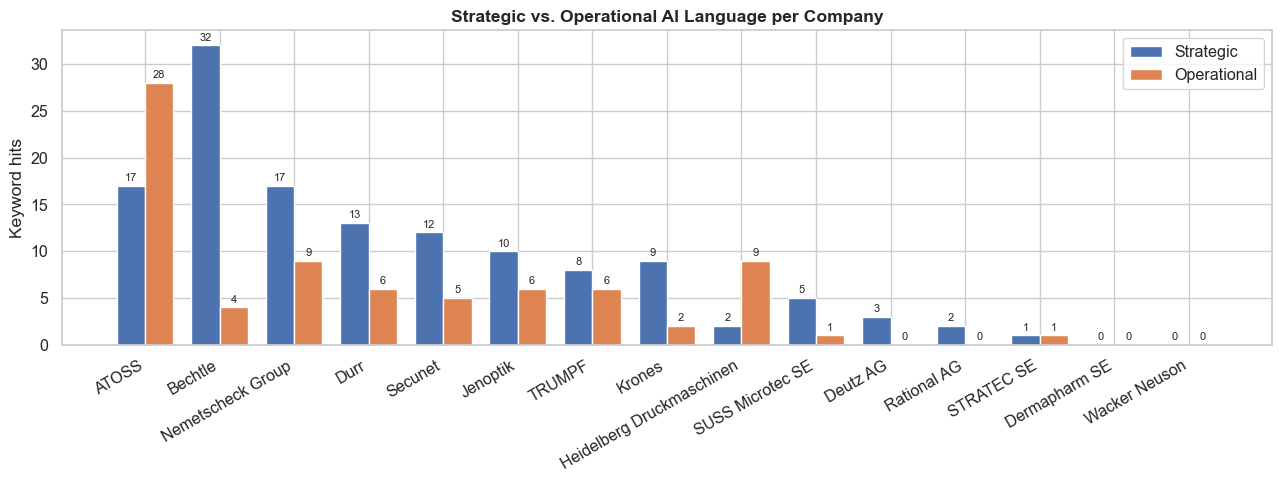

In [8]:
# ── Chart 1: Grouped bar — strategic vs operational hits per company ──────────
df_sorted = df.sort_values("total_ai_mentions", ascending=False)
companies = df_sorted["company"].tolist()
x = np.arange(len(companies))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, df_sorted["strategic_hits"],   w, label="Strategic",   color="#4C72B0")
b2 = ax.bar(x + w/2, df_sorted["operational_hits"], w, label="Operational", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(companies, rotation=30, ha="right")
ax.set_ylabel("Keyword hits")
ax.set_title("Strategic vs. Operational AI Language per Company", fontweight="bold")
ax.legend()
ax.bar_label(b1, padding=2, fontsize=8)
ax.bar_label(b2, padding=2, fontsize=8)
plt.tight_layout()
plt.savefig("chart1_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/zj/s_00dydx0lz0p48fn1v8_6_m0000gn/T/ipykernel_9075/1947528732.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["company"], rotation=30, ha="right")


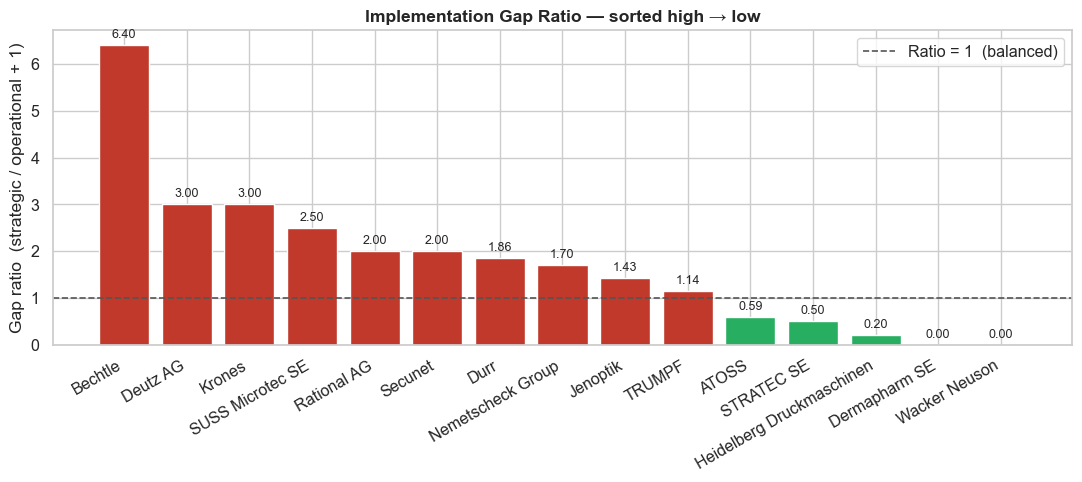

In [9]:
# ── Chart 2: Sorted gap-ratio bar — implementation gap ranking ────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors  = ["#c0392b" if r > 1.0 else "#27ae60" for r in df["gap_ratio"]]
bars    = ax.bar(df["company"], df["gap_ratio"], color=colors, edgecolor="white")
ax.axhline(1.0, color="#555", linestyle="--", linewidth=1.2, label="Ratio = 1  (balanced)")
ax.set_ylabel("Gap ratio  (strategic / operational + 1)")
ax.set_title("Implementation Gap Ratio — sorted high → low", fontweight="bold")
ax.set_xticklabels(df["company"], rotation=30, ha="right")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("chart2_gap_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

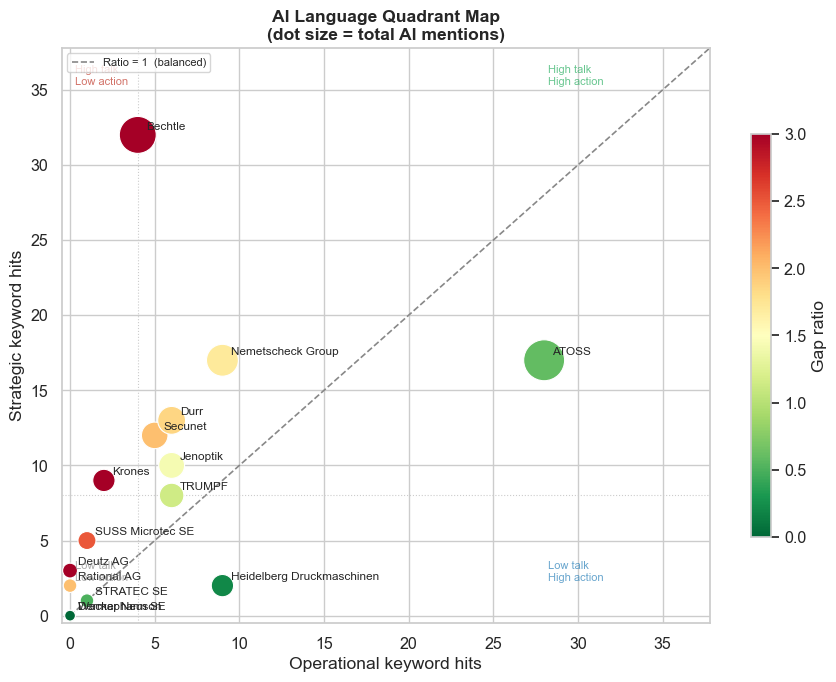

In [10]:
# ── Chart 3: Scatter — strategic vs operational (quadrant view) ───────────────
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(df["operational_hits"], df["strategic_hits"],
           s=df["total_ai_mentions"] * 18 + 60,
           c=df["gap_ratio"], cmap="RdYlGn_r", vmin=0, vmax=3,
           edgecolors="white", linewidths=0.8, zorder=3)

# Diagonal: balanced line (ratio = 1)
lim = max(df[["strategic_hits", "operational_hits"]].max()) * 1.15 + 1
ax.plot([0, lim], [0, lim], "--", color="#888", linewidth=1.2, label="Ratio = 1  (balanced)")

# Quadrant shading
ax.axvline(df["operational_hits"].median(), color="#ccc", linewidth=0.8, linestyle=":")
ax.axhline(df["strategic_hits"].median(),   color="#ccc", linewidth=0.8, linestyle=":")

# Annotate each company
for _, row in df.iterrows():
    ax.annotate(row["company"],
                xy=(row["operational_hits"], row["strategic_hits"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8.5)

# Quadrant labels
ax.text(0.02, 0.97, "High talk\nLow action",  transform=ax.transAxes, va="top",   fontsize=8, color="#c0392b", alpha=0.7)
ax.text(0.75, 0.97, "High talk\nHigh action", transform=ax.transAxes, va="top",   fontsize=8, color="#27ae60", alpha=0.7)
ax.text(0.02, 0.07, "Low talk\nLow action",   transform=ax.transAxes, va="bottom",fontsize=8, color="#888",    alpha=0.7)
ax.text(0.75, 0.07, "Low talk\nHigh action",  transform=ax.transAxes, va="bottom",fontsize=8, color="#2980b9", alpha=0.7)

ax.set_xlabel("Operational keyword hits")
ax.set_ylabel("Strategic keyword hits")
ax.set_title("AI Language Quadrant Map\n(dot size = total AI mentions)", fontweight="bold")
ax.legend(loc="upper left", fontsize=8)
plt.colorbar(ax.collections[0], ax=ax, label="Gap ratio", shrink=0.7)
ax.set_xlim(-0.5, lim)
ax.set_ylim(-0.5, lim)
plt.tight_layout()
plt.savefig("chart3_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()

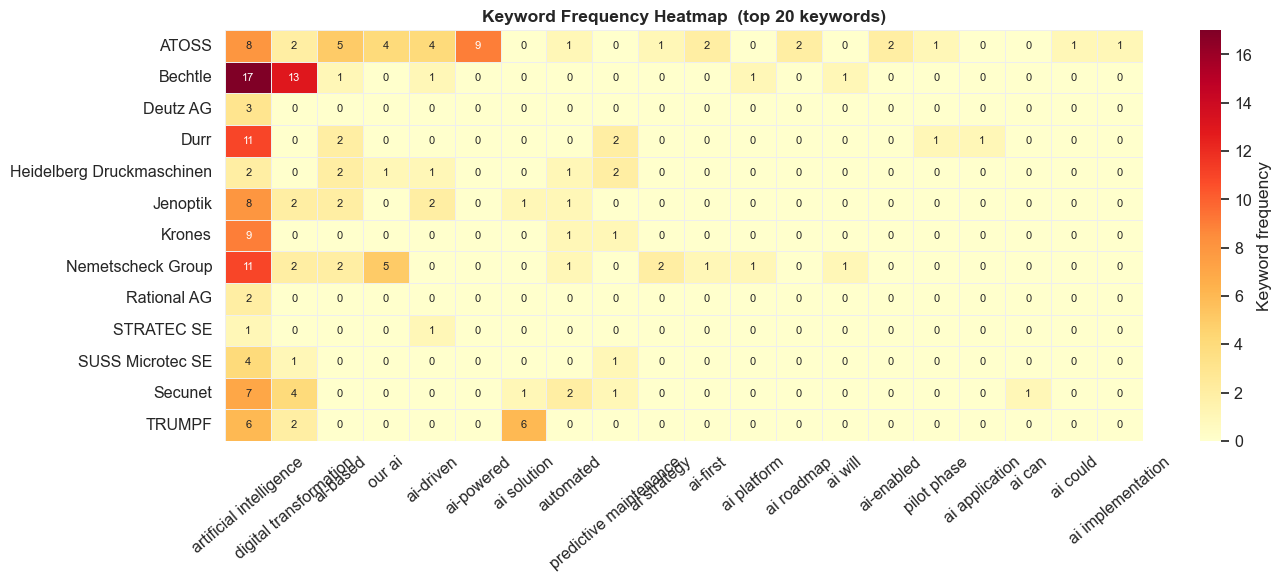

In [11]:
# ── Chart 4: Heatmap — top keyword hits per company ──────────────────────────
# Build a company × keyword matrix (top keywords by total frequency)
pivot = (
    df_detail
    .groupby(["company", "keyword"])["count"].sum()
    .reset_index()
    .pivot(index="company", columns="keyword", values="count")
    .fillna(0)
)

# Keep only the top-N most frequent keywords across all companies
TOP_N = 20
top_kws = pivot.sum().nlargest(TOP_N).index
pivot   = pivot[top_kws]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd", linewidths=0.4, linecolor="#eee",
    annot=True, fmt=".0f", annot_kws={"size": 8},
    cbar_kws={"label": "Keyword frequency"}
)
ax.set_title(f"Keyword Frequency Heatmap  (top {TOP_N} keywords)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.savefig("chart4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

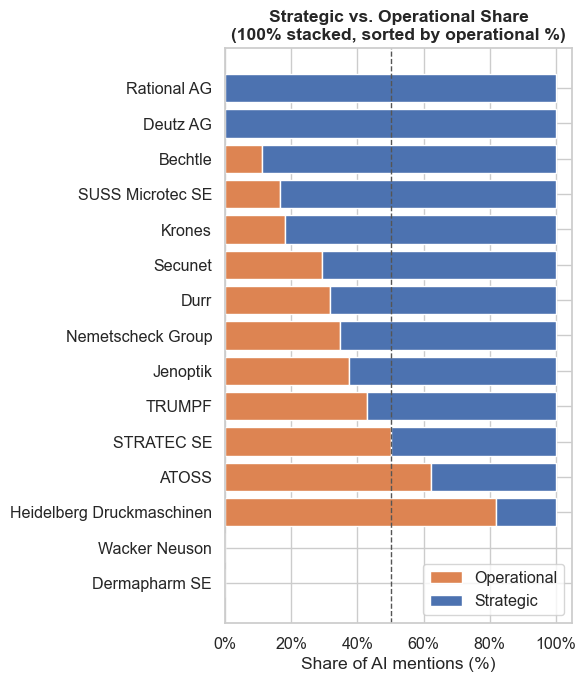

In [12]:
# ── Chart 5: Stacked 100% bar — strategic/operational share per company ───────
df_share = df.copy()
total    = (df_share["strategic_hits"] + df_share["operational_hits"]).replace(0, 1)
df_share["pct_strategic"]   = df_share["strategic_hits"]   / total * 100
df_share["pct_operational"] = df_share["operational_hits"] / total * 100
df_share = df_share.sort_values("pct_strategic", ascending=True)  # most operational first → naturally ordered

fig, ax = plt.subplots(figsize=(6, 7))
ax.barh(df_share["company"], df_share["pct_operational"], color="#DD8452", label="Operational")
ax.barh(df_share["company"], df_share["pct_strategic"],   left=df_share["pct_operational"],
        color="#4C72B0", label="Strategic")
ax.axvline(50, color="#555", linestyle="--", linewidth=1)
ax.set_xlabel("Share of AI mentions (%)")
ax.set_title("Strategic vs. Operational Share\n(100% stacked, sorted by operational %)", fontweight="bold")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig("chart5_stacked_share.png", dpi=150, bbox_inches="tight")
plt.show()

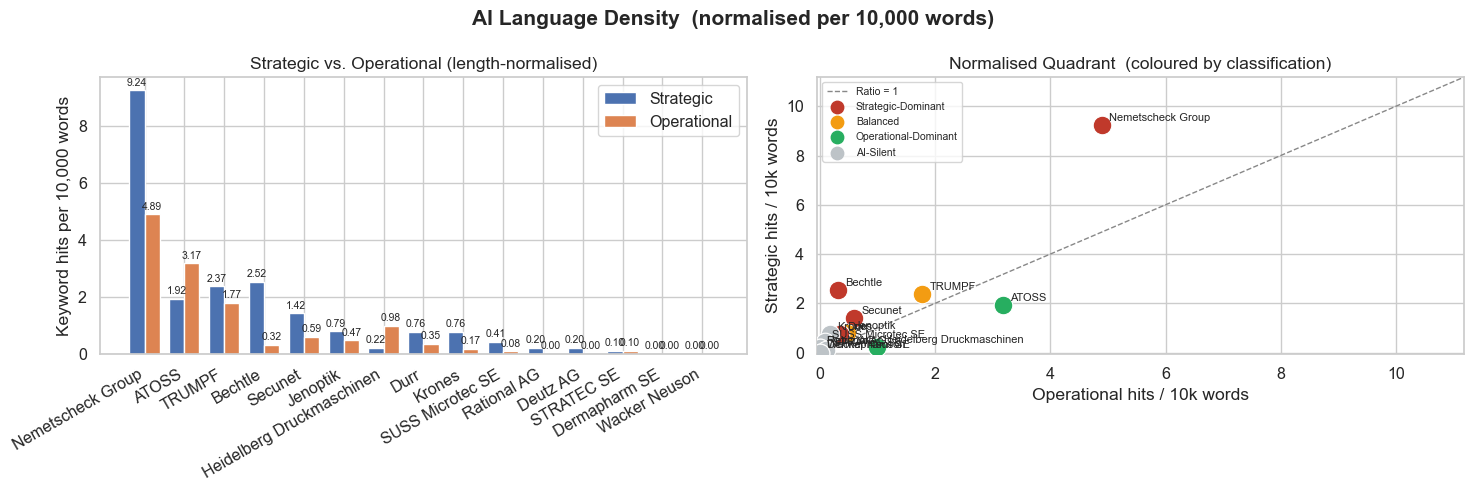


Classification breakdown:
                  company  total_words  total_per_10k  gap_ratio       classification
                  Bechtle       126914          2.837     6.4000   Strategic-Dominant
                 Deutz AG       150379          0.199     3.0000            AI-Silent
                   Krones       118070          0.932     3.0000            AI-Silent
         SUSS Microtec SE       120528          0.498     2.5000            AI-Silent
              Rational AG        99997          0.200     2.0000            AI-Silent
                  Secunet        84814          2.004     2.0000   Strategic-Dominant
                     Durr       170607          1.114     1.8571   Strategic-Dominant
        Nemetscheck Group        18406         14.126     1.7000   Strategic-Dominant
                 Jenoptik       126466          1.265     1.4286             Balanced
                   TRUMPF        33804          4.142     1.1429             Balanced
                    ATOSS  

In [13]:
# ── Chart 6: Normalised grouped bar — per 10,000 words ───────────────────────
CLASS_COLORS = {
    "Strategic-Dominant":   "#c0392b",
    "Balanced":             "#f39c12",
    "Operational-Dominant": "#27ae60",
    "AI-Silent":            "#bdc3c7",
}

df_norm = df.sort_values("total_per_10k", ascending=False)
x = np.arange(len(df_norm))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("AI Language Density  (normalised per 10,000 words)", fontweight="bold")

# Left: grouped bar normalised
ax1 = axes[0]
b1 = ax1.bar(x - w/2, df_norm["strategic_per_10k"],   w, label="Strategic",   color="#4C72B0")
b2 = ax1.bar(x + w/2, df_norm["operational_per_10k"], w, label="Operational", color="#DD8452")
ax1.set_xticks(x)
ax1.set_xticklabels(df_norm["company"], rotation=30, ha="right")
ax1.set_ylabel("Keyword hits per 10,000 words")
ax1.set_title("Strategic vs. Operational (length-normalised)")
ax1.legend()
ax1.bar_label(b1, fmt="%.2f", padding=2, fontsize=7.5)
ax1.bar_label(b2, fmt="%.2f", padding=2, fontsize=7.5)

# Right: classification dot chart
ax2 = axes[1]
for _, row in df_norm.iterrows():
    color = CLASS_COLORS.get(row["classification"], "#999")
    ax2.scatter(row["operational_per_10k"], row["strategic_per_10k"],
                s=180, color=color, edgecolors="white", linewidths=0.8, zorder=3)
    ax2.annotate(row["company"], xy=(row["operational_per_10k"], row["strategic_per_10k"]),
                 xytext=(5, 3), textcoords="offset points", fontsize=8)

lim = max(df_norm[["strategic_per_10k", "operational_per_10k"]].max()) * 1.2 + 0.1
ax2.plot([0, lim], [0, lim], "--", color="#888", linewidth=1, label="Ratio = 1")
ax2.set_xlabel("Operational hits / 10k words")
ax2.set_ylabel("Strategic hits / 10k words")
ax2.set_title("Normalised Quadrant  (coloured by classification)")
ax2.set_xlim(-0.05, lim)
ax2.set_ylim(-0.05, lim)

# Legend for classification colours
for label, color in CLASS_COLORS.items():
    ax2.scatter([], [], color=color, label=label, s=80)
ax2.legend(fontsize=7.5, loc="upper left")

plt.tight_layout()
plt.savefig("chart6_normalised.png", dpi=150, bbox_inches="tight")
plt.show()

# Classification summary
print("\nClassification breakdown:")
print(df[["company", "total_words", "total_per_10k", "gap_ratio", "classification"]]
      .to_string(index=False))

## Sentence-Level Evidence

In [14]:
print(f"Total keyword-bearing sentences across all reports: {len(df_contexts)}")
df_contexts.head(15)

Total keyword-bearing sentences across all reports: 277


,company,category,keyword,sentence
0,ATOSS,strategic,ai could,A study by the so that neither quality nor wor...
1,ATOSS,strategic,artificial intelligence,"Data-driven planATOSS, about why companies mus..."
2,ATOSS,strategic,artificial intelligence,It is the layer Artificial intelligence repres...
3,ATOSS,strategic,pilot phase,We had virtually no pilot phase because we gre...
4,ATOSS,strategic,artificial intelligence,"At the same time, new technologies—particu- AI..."
5,ATOSS,strategic,artificial intelligence,We were also ranked fourth among Germany’s are...
6,ATOSS,strategic,digital transformation,The operational frontline ed their skill sets ...
7,ATOSS,strategic,artificial intelligence,I am convinced that artificial intelligence wi...
8,ATOSS,strategic,ai-first,ATOSS How do you envision the ATOSS products e...
9,ATOSS,strategic,ai-first,We see our portfolio converging into a single ...
